In [1]:
import os
from glob import glob
import mrcfile
import matplotlib.pyplot as plt
from core.vtk_utilities import *
from core.utilities import *
from core.widgets_utilities import *
from core.all_features2 import all_features2
from core.tk_utilities import *


In [2]:
use_pns_list = [
    "/home/tomo/kaggle/polnet/data/in_10A_czii/1fa2_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A_czii/6cvm_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A_czii/6n4v_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A_czii/6qzp_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A_czii/6z6u_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A_czii/7N4Y_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A_czii/8vaf_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A/3j9i_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A/1u6g_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A/2uv8_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A/3h84_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A/4cr2_10A.pns",
    "/home/tomo/kaggle/polnet/data/in_10A/5mrc_10A.pns",
]

use_mbs_list = [
    "/home/tomo/kaggle/polnet/data/in_mbs/ellipse.mbs",
    # "/home/tomo/kaggle/polnet/data/in_mbs/sphere.mbs",
    # "/home/tomo/kaggle/polnet/data/in_mbs/toroid.mbs",
]

use_hns_list = [
    "/home/tomo/kaggle/polnet/data/in_helix/actin.hns",
    "/home/tomo/kaggle/polnet/data/in_helix/mt.hns",
]

#### 1. `tries_mmer`

- **説明**: 1つのモノマー（単位構造）を配置する際に試行する回数の上限を指定します。指定された回数だけモノマーの配置を試み、それでも配置に失敗した場合は新しいポリマーの開始を試みます。
  
- **用途**:
  - モノマーの配置が困難な場合に無限ループに陥るのを防ぐため。
  - ポリマーの生成プロセスの効率化。

#### 1. `tries_pmer`

- **説明**: 1つのポリマー全体を配置する際に試行する回数の上限を指定します。指定された回数だけポリマーの配置を試み、それでも配置に失敗した場合はポリマーの生成を中止します。
  
- **用途**:
  - ポリマー全体の配置が困難な場合に生成プロセスを中断するため。
  - 全体としてのポリマー配置の品質を保つため。

surf_dec, [0, 1), ポリゴンの削減率（値が大きいほど削減する）
tilt_angs, -90~90の範囲の値のリスト, どの角度から3D->2D射影をするか（範囲が大きいほど詳細、値が細かいほど詳細）
detector_snr, 正の値, 加えるノイズのSN比（大きいほどノイズのレベルが低くなる）、長さ2のリストで与えた場合その範囲でランダム選択（こっちで作ったランダムなスカラーで与えるのが良さそう）
malign_mn, malign_mx, malign_sg, 正の値、mx >= mn, 
ティルトシリーズ内の各マイクログラフにランダムなXおよびYのミスアライメント（ずれ）を追加します。ミスアライメントはサイン波モデルに基づいており、各ティルト角度に応じて変動します。また、ガウスノイズを加えることで、実際のデータに近いランダムなずれをシミュレートします。

1. **mn (minimum misalignment value)**:
    - **説明**: ティルト角が0度のときの最小ずれ量を設定します。値が大きいほど、最低限のずれが大きくなります。

2. **mx (maximum misalignment value)**:
    - **説明**: ティルト角が最大角度のときの最大ずれ量を設定します。値が大きいほど、最大限ずれる範囲が広がります。

3. **n_sigma (sigma value for Gaussian noise)**:
    - **説明**: ガウスノイズの標準偏差を設定します。値が大きいほど、ずれに加わるランダムなノイズの影響が大きくなり、結果としてずれが不規則に大きくなります。


1: 0.9
GENERATING TOMOGRAM NUMBER: 0
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_mbs/ellipse.mbs
Membrane 1, total occupancy: 0.0018021415973796925, volume: 71527000, thickness: 25.674651352344252, layer_s: 1.8125899566166002, radius (avg): 618.5207178285295
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_helix/actin.hns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_helix/mt.hns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A_czii/1fa2_10A.pns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A_czii/6cvm_10A.pns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A_czii/6n4v_10A.pns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A_czii/6qzp_10A.pns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A_czii/6z6u_10A.pns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A_czii/7N4Y_10A.pns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A_czii/8vaf_10A.pns
	PROCESSING FILE: /home/tomo/kaggle/polnet/data/in_10A/3j9i_10A.pns
	PROCESSING FILE: /home/

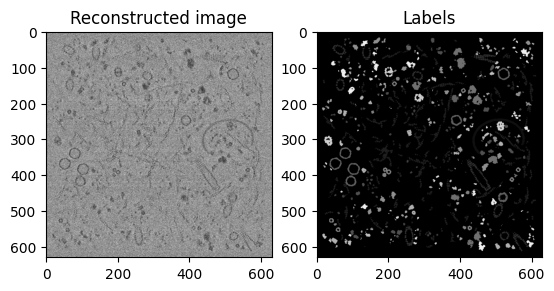

In [3]:
target_param="surf_dec"
param_list = [0.9]

for i, value in enumerate(param_list):
    print(f"{i + 1}: {value}")
    # Define the output directory
    output_directory = os.path.join("/home/tomo/kaggle/polnet/data_generated", target_param, f"output_{i + 1}_{value}")

    # Define the parameters for the all_features2 function
    ntomos = 1
    voi_shape = (630, 630, 100)
    x = voi_shape[0]; y = voi_shape[1]; z = voi_shape[2]
    voi_off = ((int(x * 0.025), int(x * 0.975)), 
                (int(y * 0.025), int(y * 0.975)), 
                (int(z * 0.025), int(z * 0.975)) )
    voi_size = 10
    mmer_tries = 20
    pmer_tries = 100
    membranes_list = use_mbs_list
    helix_list = use_hns_list
    proteins_list = use_pns_list
    mb_proteins_list = []
    surf_dec = 0.9
    tilt_angs = range(-120, 121, 3)
    detector_snr = 2 #[0.5, 2]
    malign_mn = 1
    malign_mx = 5
    malign_sg = 0.5

    # Generate the synthetic dataset
    all_features2(ntomos, voi_shape, output_directory, voi_off, voi_size, mmer_tries, pmer_tries,
                membranes_list, helix_list, proteins_list, mb_proteins_list, surf_dec, tilt_angs,
                detector_snr, malign_mn, malign_mx, malign_sg)

    # Visualize the generated data
    image_file = glob(os.path.join(output_directory, 'tomos', 'tomo_rec_0_snr*.mrc'))[0]
    with mrcfile.open(image_file, permissive=True) as mrc:
        data = mrc.data
    plt.subplot(1, 2, 1)
    plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
    plt.title('Reconstructed image')

    label_file = os.path.join(output_directory, 'tomos', 'tomo_lbls_0.mrc')
    with mrcfile.open(label_file, permissive=True) as mrc:
        data = mrc.data
    plt.subplot(1, 2, 2)
    plt.imshow(data[data.shape[0] // 2, :, :], cmap='gray')
    plt.title('Labels')

    plt.savefig(os.path.join(output_directory, 'visualization.png'))